In [52]:
# imports
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import mlflow
import mlflow.lightgbm
import warnings
import shap
from mlflow.tracking import MlflowClient
from pathlib import Path

repo_root = Path.cwd().parent  # Add project root to sys.path
sys.path.insert(0, str(repo_root))

from src import utils

warnings.filterwarnings("ignore")


In [53]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

### ARIMA + GARCH + LightGBM

2017-01-02 → ['JPM', 'GS', 'MS']
2017-02-01 → ['WFC', 'BAC', 'MS']
2017-03-03 → ['AAPL', 'BAC', 'MS']
2017-04-04 → ['NKE', 'MS', 'BAC']
2017-05-04 → ['TSLA', 'MSFT', 'KO']
2017-06-05 → ['BAC', 'TSLA', 'GS']
2017-07-05 → ['MS', 'NVDA', 'BAC']
2017-08-04 → ['TSLA', 'MS', 'ORCL']
2017-09-05 → ['NVDA', 'TSLA', 'NKE']
2017-10-05 → ['ORCL', 'TSLA', 'NVDA']


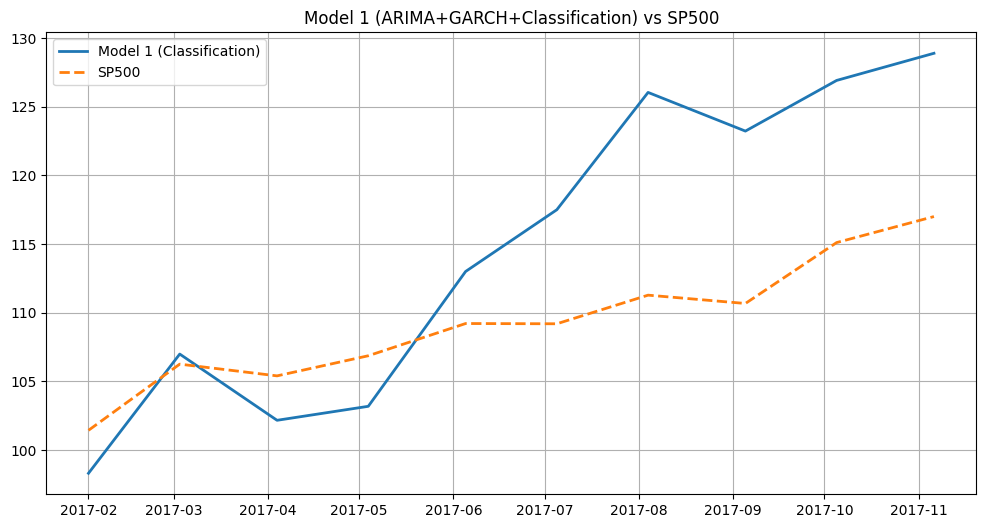

Final Alpha: 11.887254880075702


In [ ]:
# --- MLflow experiment ---
mlflow.set_experiment("Model_1_Classification_Backtest")

# --- Paths ---
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# --- Load data ---
def load_all_data():
    """
    Load SPY and selected stock data from CSV files.

    Returns
    -------
    spy : pandas.DataFrame
        DataFrame with SPY prices indexed by Date. Must contain at least 'Close'.
        A log return column 'Ret' is added: Ret = log(Close / Close.shift(1)).
    stock_dfs : dict
        Dictionary mapping ticker (str) -> pandas.DataFrame for each stock found in
        the stocks_path and listed in `sector_map`. Each DataFrame is indexed by Date,
        sorted, and contains a 'Ret' column with log returns.

    Notes
    -----
    - Expects files named like "<ticker>_clean.csv" (ticker lowercased) in stocks_path.
    - Parses dates using pandas.read_csv(..., parse_dates=True, index_col='Date').
    - Returns only tickers whose files exist on disk.
    """
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy['Ret'] = np.log(spy['Close'] / spy['Close'].shift(1))

    stock_dfs = {}
    for ticker in sector_map.keys():
        f_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(f_path):
            df = pd.read_csv(f_path, index_col='Date', parse_dates=True).sort_index()
            df['Ret'] = np.log(df['Close'] / df['Close'].shift(1))
            stock_dfs[ticker] = df

    return spy, stock_dfs

df_spy, df_stocks = load_all_data()

# --- Feature extraction ---
def extract_features_for_date(date_point, horizon=22):
    """
    Compute ARIMA/GARCH and simple technical features for all stocks at a given date.

    Parameters
    ----------
    date_point : str or pandas.Timestamp
        Reference date (inclusive) used to cut historical data and compute features.
    horizon : int, optional
        Forecast horizon (in trading days) used to define the "future" period for
        the target and for checking enough data. Default is 22.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame with one row per ticker containing:
        - Date, Ticker
        - feat_arima : float (ARIMA(1,0,1) 1-step forecast on last 20 returns)
        - feat_garch : float (GARCH(1,1) 1-step forecast volatility on last 60 returns)
        - feat_momentum : float (log return over last 20 closes)
        - feat_volatility : float (std of last 20 returns)
        - feat_dist_ma200 : float (distance to 200-day moving average; 0.0 if <200 days)
        - target : int (1 if stock outperforms SPY over horizon, else 0)

    Notes
    -----
    - Uses global variables df_spy and df_stocks.
    - Returns None when there is not enough historical or future data.
    - Exceptions in ARIMA/GARCH fitting are caught and replaced with fallback values.
    """
    features = []

    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 60:
        return None

    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon:
        return None

    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])

    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]

        if len(df_cut) < 60 or len(df_future) < horizon:
            continue

        rets20 = df_cut['Ret'].tail(20).dropna()
        rets60 = df_cut['Ret'].tail(60).dropna()

        # ARIMA
        try:
            m_arima = ARIMA(rets20, order=(1,0,1)).fit()
            feat_arima = m_arima.forecast(1).values[0]
        except:
            feat_arima = 0.0

        # GARCH
        try:
            m_garch = arch_model(rets60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
            feat_garch = np.sqrt(m_garch.forecast(horizon=1).variance.values[-1][0])
        except:
            feat_garch = rets60.std()

        # Simple features
        mom20 = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-20])
        vol20 = rets20.std()

        # MA200
        if len(df_cut) >= 200:
            ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
            dist_ma200 = (df_cut['Close'].iloc[-1] - ma200) / ma200
        else:
            dist_ma200 = 0.0

        # TARGET: outperform?
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        target = int(stock_future_ret > spy_future_ret)

        features.append({
            'Date': date_point,
            'Ticker': ticker,
            'feat_arima': feat_arima,
            'feat_garch': feat_garch,
            'feat_momentum': mom20,
            'feat_volatility': vol20,
            'feat_dist_ma200': dist_ma200,
            'target': target
        })

    return pd.DataFrame(features) if features else None

# --- Walk-forward classification with MLflow ---
trading_days = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days[i] for i in range(0, len(trading_days), 22)]

portfolio_returns = []
spy_returns = []
test_dates = []

with mlflow.start_run(run_name="Model_1_Classification_Backtest"):

    mlflow.log_param("model_type", "LightGBM Classification")
    mlflow.log_param("features", "ARIMA, GARCH, momentum20, volatility20, dist_MA200")
    mlflow.log_param("rebalance_frequency", "22 days")

    for step in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates[step]
        next_date = rebalance_dates[step + 1]

        # Training set
        hist_dates = df_spy.loc[:current_date].index[-300::22]
        train_rows = []

        for d in hist_dates:
            df_feat = extract_features_for_date(d)
            if df_feat is not None:
                train_rows.append(df_feat)

        if not train_rows:
            continue

        df_train = pd.concat(train_rows, ignore_index=True)

        feature_cols = ['feat_arima', 'feat_garch', 'feat_momentum', 'feat_volatility', 'feat_dist_ma200']
        X_train = df_train[feature_cols]
        y_train = df_train['target']

        # Nested MLflow run
        with mlflow.start_run(nested=True, run_name=f"Step_{step}"):

            train_dataset = lgb.Dataset(X_train, label=y_train)
            params = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'learning_rate': 0.05,
                'max_depth': 4,
                'verbose': -1
            }

            model1 = lgb.train(params, train_dataset, num_boost_round=60)

            mlflow.lightgbm.log_model(model1, name=f"model_step_{step}")

            # Prediction
            df_test = extract_features_for_date(current_date)
            if df_test is None or df_test.empty:
                continue

            
            # --- sanity check: data leakage inspection ---
            train_dates = df_train['Date'].tolist()
            test_date = df_test['Date'].iloc[0]

            if utils.check_data_leakage(train_dates, test_date):
                raise RuntimeError(f"Data leakage detected for test date {test_date}")

            # Prediction continues
            X_test1 = df_test[feature_cols]
            df_test['prob'] = model1.predict(X_test1)

            top3 = df_test.sort_values(by='prob', ascending=False).head(3)
            tickers = top3['Ticker'].tolist()

            print(f"{current_date.date()} → {tickers}")

            # Returns
            spy_period = df_spy.loc[current_date:next_date]
            spy_ret = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
            spy_returns.append(spy_ret)

            stock_rets = []
            for t in tickers:
                s_df = df_stocks[t].loc[current_date:next_date]
                s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
                stock_rets.append(s_ret)

            portfolio_returns.append(np.mean(stock_rets))
            test_dates.append(next_date)

            # --- alpha for this step ---
            alpha_step = utils.calculate_forward_alpha(np.mean(stock_rets), spy_ret)
            mlflow.log_metric(f"alpha_step_{step}", alpha_step)

            # Final metrics
            cum_portfolio = np.cumprod(1 + np.array(portfolio_returns)) * 100
            cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

            final_alpha = (cum_portfolio[-1] - 100) - (cum_spy[-1] - 100)

            mlflow.log_metric("final_alpha", final_alpha)
            mlflow.log_metric("final_portfolio_return", cum_portfolio[-1])
            mlflow.log_metric("final_sp500_return", cum_spy[-1])

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(test_dates, cum_portfolio, label="Model 1 (Classification)", lw=2)
plt.plot(test_dates, cum_spy, label="SP500", lw=2, ls='--')
plt.legend()
plt.grid(True)
plt.title("Model 1 (ARIMA+GARCH+Classification) vs SP500")
plt.show()

print("Final Alpha:", final_alpha)


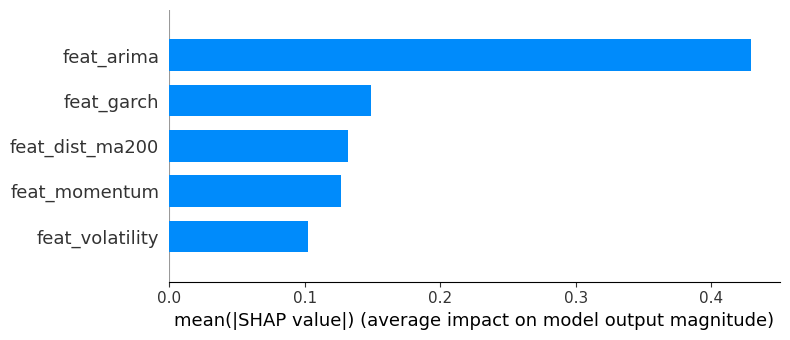

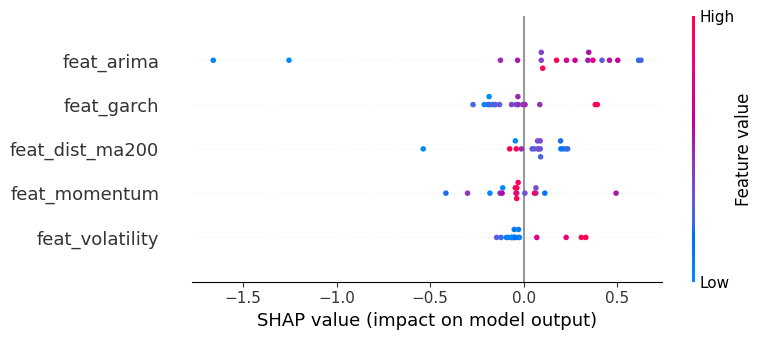

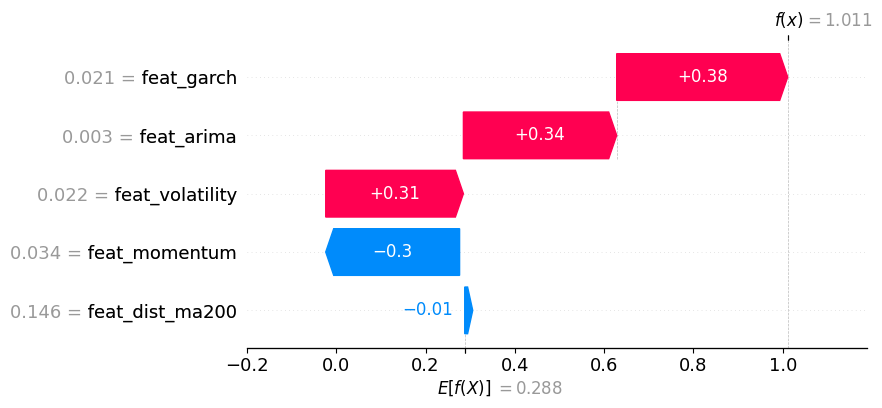

In [55]:
# --- pick the last walk-forward model ---
final_model1 = model1  # last model from walk-forward for model 1
final_X_test1 = X_test1  # X_test from last step of model 1

# --- SHAP TreeExplainer for model 1 ---
explainer1 = shap.TreeExplainer(final_model1)
shap_values1 = explainer1.shap_values(final_X_test1)

# --- Global importance (bar plot) ---
shap.summary_plot(shap_values1, final_X_test1, plot_type="bar")

# --- Beeswarm: feature effect direction ---
shap.summary_plot(shap_values1, final_X_test1)

# --- Waterfall for a single stock (e.g., TSLA) ---
i = df_test.index[df_test['Ticker'] == 'TSLA'][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values1[i],
        base_values=explainer1.expected_value,
        data=final_X_test1.iloc[i],
        feature_names=final_X_test1.columns
    )
)

Model 1 - interpretation:

- The most important feature is ARIMA prediction about beating S&P500,
- GARCH volatility is the second-important feature (we can see that is far less iportant than ARIMA),
- distance to 200-day average, 20-day momentum  and (local) volatility have average influence on the model.

Scatter plot:

- If ARIMA gives high values, the probabilty of outperforming increases, low values affect the model negatively.
- GARCH works similarly, but affects the model less, mean values don't affect the model that much (bu slightly neagatively).
- High distance to MA200 gives slightly negative impact, but low values gives far more negative impact (see the blue dot on the left)
- Momentum doesn't behave so straightforward, because we see different colors on both sides of the ax.
- Local volatility - low values affect the model slightly negatively, high values affect positively.

Waterfall:
- $\mathbb{E}(f(X)) = 0.288$ is the base log-prediction of the model. For a chosed stock (`TSLA`) we showed a waterfall plot with the "thought process" of the model and how the value of $f$ changed with each component (feature):
    - the model adds first because of low distance to MA200
    - subtracts because of (poor) momentum 
    - ahen adds thanks to volatility,
    - adds thanks to ARIMA
    - adds thanks to GARCH 

    finishing with the final score $f = 1.011$ (we can calculate the probability using the formula $p = 1/ (a+ e^{-f(x)})$ if we want).

### new model, without ARIMA or GARCH

In [56]:
def extract_features_2(date_point, horizon=22):
    """
    Compute momentum, volatility, relative and calendar features for each stock at a date.

    Parameters
    ----------
    date_point : str or pandas.Timestamp
        Reference (cut-off) date for historical data.
    horizon : int, optional
        Number of trading days used to define the future window for the target.
        Default is 22.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame with columns:
        - Date, Ticker
        - mom_5, mom_10, mom_20, mom_60 : sum of log returns over last X days
        - vol_20, vol_60 : std of returns over last X days
        - rel_mom_20_spy, rel_mom_60_spy : momentum relative to SPY
        - rel_mom_20_sector, rel_mom_60_sector : momentum relative to sector ETF (NaN if not available)
        - vol_rel_20, vol_rel_60 : volume last / mean volume over X days
        - day_of_week, month, is_month_end, is_quarter_end : calendar features
        - target : int (1 if future stock return > future SPY return over horizon)

    Notes
    -----
    - Uses global df_spy, df_stocks and sector_map; reads sector ETF files when available.
    - Returns None if there is insufficient historical or future data.
    - Volume-based features assume 'Volume' column exists in stock CSVs.
    """
    features = []

    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 120:
        return None

    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon:
        return None

    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])
    spy_rets = spy_cut['Ret'].dropna()

    if len(spy_rets) < 60:
        return None

    spy_mom_20 = spy_rets.tail(20).sum()
    spy_mom_60 = spy_rets.tail(60).sum()

    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]

        if len(df_cut) < 120 or len(df_future) < horizon:
            continue

        rets = df_cut['Ret'].dropna()
        if len(rets) < 60:
            continue

        # Momentum
        mom_5 = rets.tail(5).sum()
        mom_10 = rets.tail(10).sum()
        mom_20 = rets.tail(20).sum()
        mom_60 = rets.tail(60).sum()

        # Volatility
        vol_20 = rets.tail(20).std()
        vol_60 = rets.tail(60).std()

        # Relative to SPY
        rel_mom_20_spy = mom_20 - spy_mom_20
        rel_mom_60_spy = mom_60 - spy_mom_60

        # Relative to sector
        sector_ticker = sector_map.get(ticker, None)
        sec_mom_20 = np.nan
        sec_mom_60 = np.nan

        if sector_ticker:
            sec_path = os.path.join(etf_path, f"{sector_ticker.lower()}_clean.csv")
            if os.path.exists(sec_path):
                df_sec = pd.read_csv(sec_path, index_col='Date', parse_dates=True).sort_index()
                df_sec['Ret'] = np.log(df_sec['Close'] / df_sec['Close'].shift(1))
                sec_rets = df_sec.loc[:date_point]['Ret'].dropna()
                if len(sec_rets) >= 60:
                    sec_mom_20 = sec_rets.tail(20).sum()
                    sec_mom_60 = sec_rets.tail(60).sum()

        rel_mom_20_sector = mom_20 - sec_mom_20 if not np.isnan(sec_mom_20) else np.nan
        rel_mom_60_sector = mom_60 - sec_mom_60 if not np.isnan(sec_mom_60) else np.nan

        # Volume
        vol_series = df_cut['Volume'].dropna()
        if len(vol_series) < 60:
            continue

        vol_mean_20 = vol_series.tail(20).mean()
        vol_mean_60 = vol_series.tail(60).mean()
        vol_last = vol_series.iloc[-1]

        vol_rel_20 = vol_last / vol_mean_20 if vol_mean_20 > 0 else 1.0
        vol_rel_60 = vol_last / vol_mean_60 if vol_mean_60 > 0 else 1.0

        # Calendar
        d = pd.Timestamp(date_point)
        day_of_week = d.weekday()
        month = d.month
        is_month_end = int(d.is_month_end)
        is_quarter_end = int(d.is_quarter_end)

        # Target
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        target = int(stock_future_ret > spy_future_ret)

        features.append({
            'Date': date_point,
            'Ticker': ticker,
            'mom_5': mom_5,
            'mom_10': mom_10,
            'mom_20': mom_20,
            'mom_60': mom_60,
            'vol_20': vol_20,
            'vol_60': vol_60,
            'rel_mom_20_spy': rel_mom_20_spy,
            'rel_mom_60_spy': rel_mom_60_spy,
            'rel_mom_20_sector': rel_mom_20_sector,
            'rel_mom_60_sector': rel_mom_60_sector,
            'vol_rel_20': vol_rel_20,
            'vol_rel_60': vol_rel_60,
            'day_of_week': day_of_week,
            'month': month,
            'is_month_end': is_month_end,
            'is_quarter_end': is_quarter_end,
            'target': target
        })

    return pd.DataFrame(features) if features else None


In [57]:
feature_cols = [
    'mom_5', 'mom_10', 'mom_20', 'mom_60',
    'vol_20', 'vol_60',
    'rel_mom_20_spy', 'rel_mom_60_spy',
    'rel_mom_20_sector', 'rel_mom_60_sector',
    'vol_rel_20', 'vol_rel_60',
    'day_of_week', 'month', 'is_month_end', 'is_quarter_end'
]

trading_days_new = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days_new[i] for i in range(0, len(trading_days_new), 22)]

portfolio_returns2 = []
spy_returns2 = []
test_dates2 = []

# --- MLflow experiment ---
mlflow.set_experiment("Model_2_Classification_Backtest")

# Start an MLflow run for Model 2 backtest
with mlflow.start_run(run_name="Model_2_Classification_Backtest"):

    mlflow.log_param("model_type", "LightGBM Classification")
    mlflow.log_param("features", "momentum, volatility, relative to SPY/sector, volume, calendar")
    mlflow.log_param("rebalance_frequency", "22 days")

    for step in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates[step]
        next_date = rebalance_dates[step + 1]

        # Training set: last 300 days every 22 days
        hist_dates = df_spy.loc[:current_date].index[-300::22]

        train_data = []
        for d in hist_dates:
            df_feat = extract_features_2(d)
            if df_feat is not None:
                train_data.append(df_feat)

        if not train_data:
            continue

        df_train = pd.concat(train_data, ignore_index=True)

        # --- sanity check: data leakage inspection ---
        train_dates = df_train['Date'].tolist()

        X_train2 = df_train[feature_cols]
        y_train2 = df_train['target']

        # Nested MLflow run per rebalancing step
        with mlflow.start_run(nested=True, run_name=f"Step_{step}_Model2"):

            mlflow.log_param("step", step)
            mlflow.log_param("train_rows", len(df_train))
            mlflow.log_param("train_unique_dates", len(hist_dates))

            train_dataset = lgb.Dataset(X_train2, label=y_train2)

            params = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'learning_rate': 0.05,
                'max_depth': 4,
                'verbose': -1
            }

            mlflow.log_params({'learning_rate': params['learning_rate'], 'max_depth': params['max_depth'], 'num_boost_round': 80})

            model2 = lgb.train(params, train_dataset, num_boost_round=80)

            # Log the trained model artifact
            mlflow.lightgbm.log_model(model2, name=f"model2_step_{step}")

            # Test
            df_test = extract_features_2(current_date)
            if df_test is None or df_test.empty:
                continue
            
            test_date = df_test['Date'].iloc[0]
            if utils.check_data_leakage(train_dates, current_date):
                raise RuntimeError(f"Data leakage detected for test date {current_date}")

            X_test2 = df_test[feature_cols]
            df_test['prob'] = model2.predict(X_test2)

            top3_ = df_test.sort_values(by='prob', ascending=False).head(3)
            tickers_ = top3_['Ticker'].tolist()

            print(f"{current_date.date()} → {tickers_}")

            # Returns
            spy_period = df_spy.loc[current_date:next_date]
            spy_ret = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
            spy_returns2.append(spy_ret)

            stock_rets = []
            for t in tickers_:
                s_df = df_stocks[t].loc[current_date:next_date]
                s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
                stock_rets.append(s_ret)

            step_port_return = np.mean(stock_rets)
            portfolio_returns2.append(step_port_return)
            test_dates2.append(next_date)

            alpha = utils.calculate_forward_alpha(np.mean(stock_rets), spy_ret)
            mlflow.log_metric(f"alpha_step{step}", alpha)

            # Log per-step metrics to MLflow (use step index for plotting consistency)
            mlflow.log_metric(f"step_portfolio_return{step}", float(step_port_return), step=step)
            mlflow.log_metric(f"step_spy_return{step}", float(spy_ret), step=step)
            mlflow.log_param(f"selected_tickers_step_{step}", ",".join(tickers_))

    # Final metrics for Model 2
    if portfolio_returns2:
        cum_portfolio2 = np.cumprod(1 + np.array(portfolio_returns2)) * 100
        cum_spy2 = np.cumprod(1 + np.array(spy_returns2)) * 100

        final_alpha2 = (cum_portfolio2[-1] - 100) - (cum_spy2[-1] - 100)

        mlflow.log_metric("final_alpha_model2", float(final_alpha2))
        mlflow.log_metric("final_portfolio_return_model2", float(cum_portfolio2[-1]))
        mlflow.log_metric("final_sp500_return_model2", float(cum_spy2[-1]))

2017-01-02 → ['ORCL', 'AMZN', 'MSFT']
2017-02-01 → ['WFC', 'AAPL', 'NVDA']
2017-03-03 → ['JNJ', 'NVDA', 'AAPL']
2017-04-04 → ['GS', 'PEP', 'WFC']
2017-05-04 → ['MRK', 'AAPL', 'GS']
2017-06-05 → ['TSLA', 'BAC', 'WFC']
2017-07-05 → ['NVDA', 'TSLA', 'GOOGL']
2017-08-04 → ['WFC', 'BAC', 'NVDA']
2017-09-05 → ['TSLA', 'NVDA', 'MSFT']
2017-10-05 → ['ABBV', 'MRK', 'NVDA']


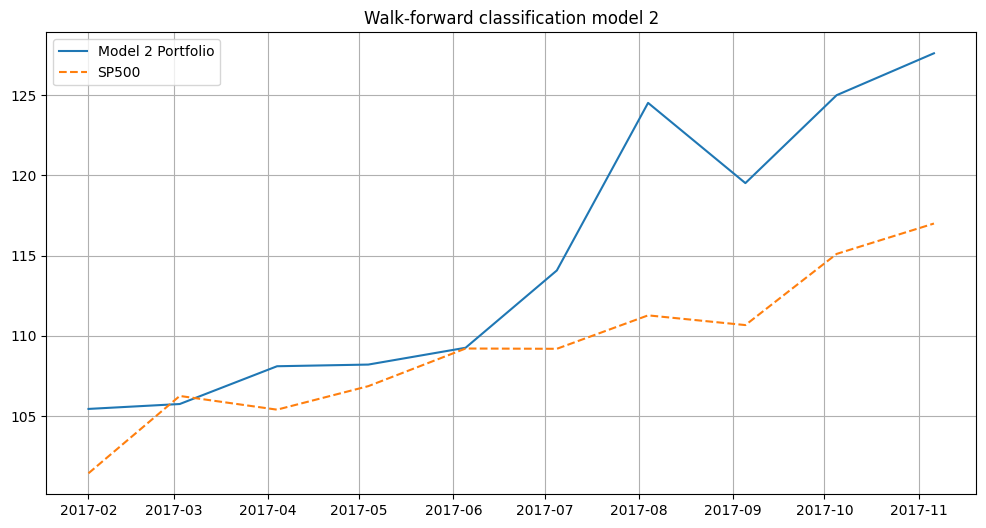

In [64]:
cum_portfolio_new = np.cumprod(1 + np.array(portfolio_returns2)) * 100
cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_dates, cum_portfolio_new, label="Model 2 Portfolio")
plt.plot(test_dates, cum_spy, label="SP500", linestyle='--')
plt.legend()
plt.grid(True)
plt.title("Walk-forward classification model 2")
plt.show()


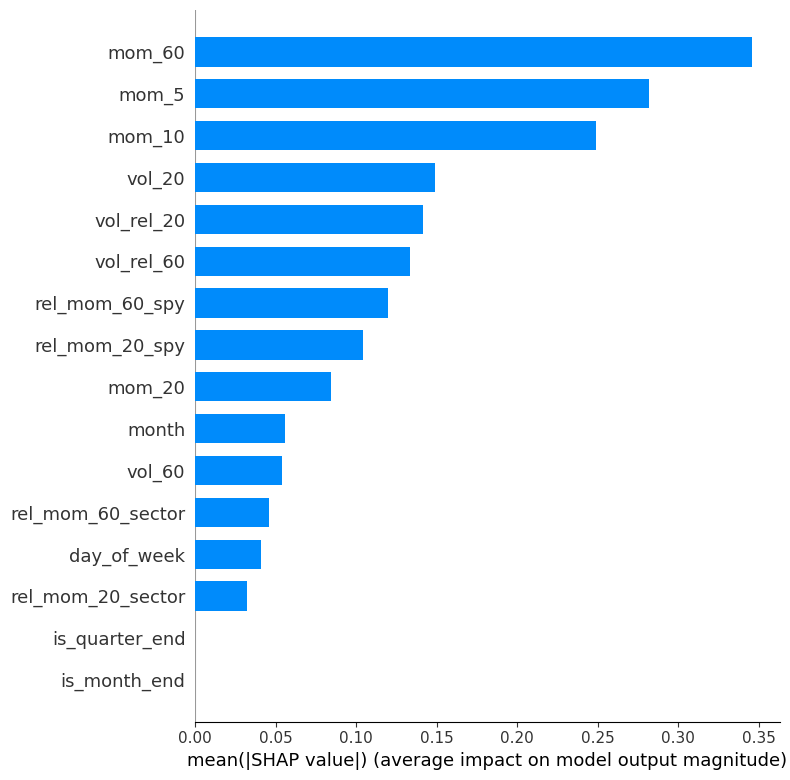

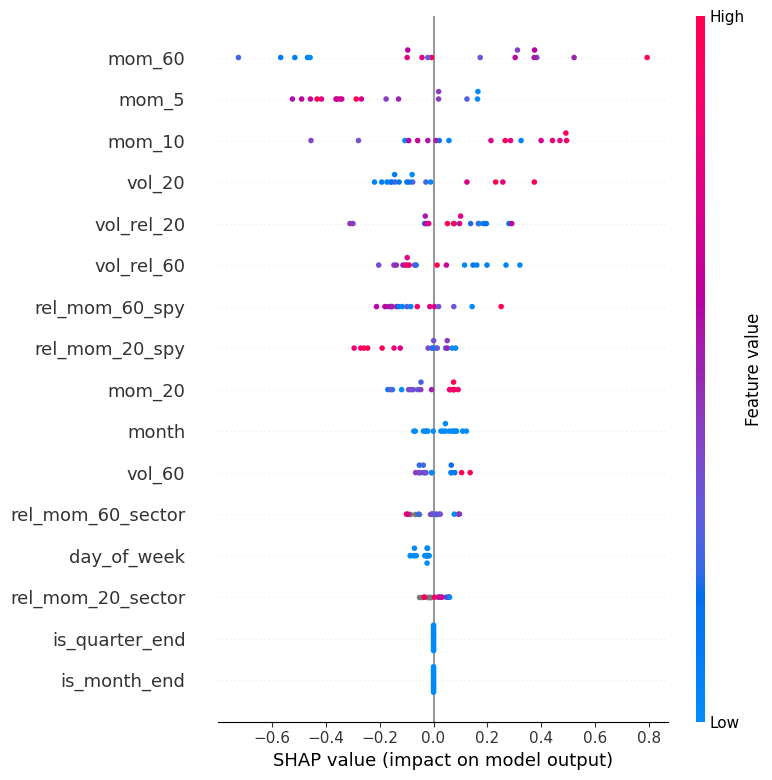

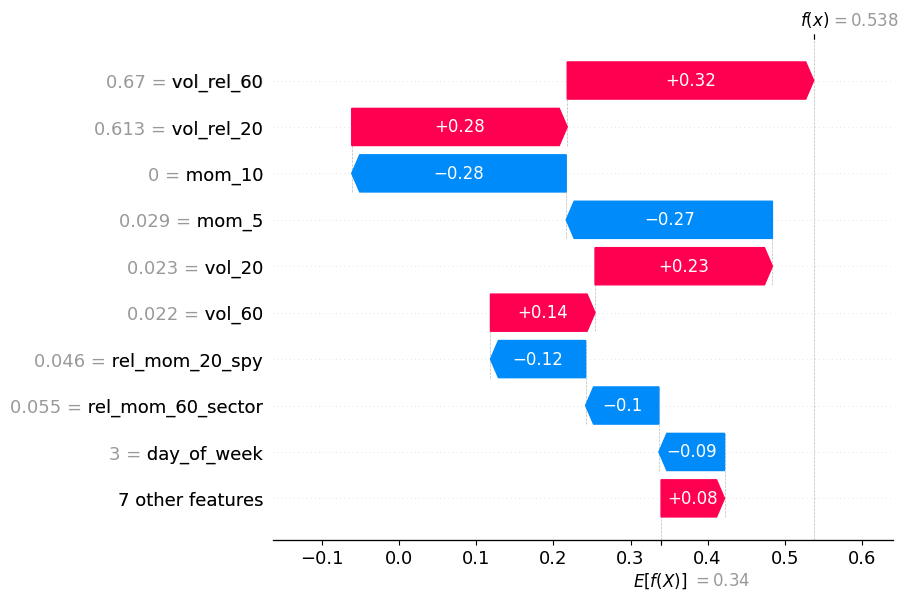

In [59]:
# --- wybieramy ostatni model z walk-forward ---
final_model2 = model2  # model z ostatniego kroku
final_X_test2 = X_test2  # X_test z ostatniego kroku

# --- SHAP TreeExplainer ---
explainer2 = shap.TreeExplainer(final_model2)
shap_values2 = explainer2.shap_values(final_X_test2)

# --- Global importance (bar plot) ---
shap.summary_plot(shap_values2, final_X_test2, plot_type="bar")

# --- Beeswarm: kierunek wpływu cech ---
shap.summary_plot(shap_values2, final_X_test2)

# --- Waterfall dla jednej spółki (np. pierwszej w X_test) ---
i = df_test.index[df_test['Ticker'] == 'NVDA'][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values2[i],
        base_values=explainer2.expected_value,
        data=final_X_test2.iloc[i],
        feature_names=final_X_test2.columns
    )
)


In the second model, the most importatnt feature are momenta (60, 5 and 10 days) so, x-day returns. Less important features are: volatility (vol_20, which is he std over previous 20 days) and relative volatility (20, 60 days) - compared to our benchmark S&P500 (the difference in volatilities). The least important components are the rest of momenta, relative momenta, month (about 0.06 importance), day of the week and relative sector momenta (60 i 20).

From the scatterplot, we can see that for example low mom_60 (and other mom_x) gives us low probablility of beating the benchmark, but high values could either affect the model slightly into the negative side (-0.1:-0.05) or, very much into positive side (0.8). vol_20 generaly works linearly - low values affect negatively, high positively, whereas mom_5, vol_rel_60, rel_mom_60_spy seem to work the other way around.

Waterfall for 'NVDA' in the 2nd model shows us that volatility generally pushes model to give higher probability, and momenta (low values, slightly over 0) pushes to the other side. In this case, low values of each feature push the probability down, and high values push it up.

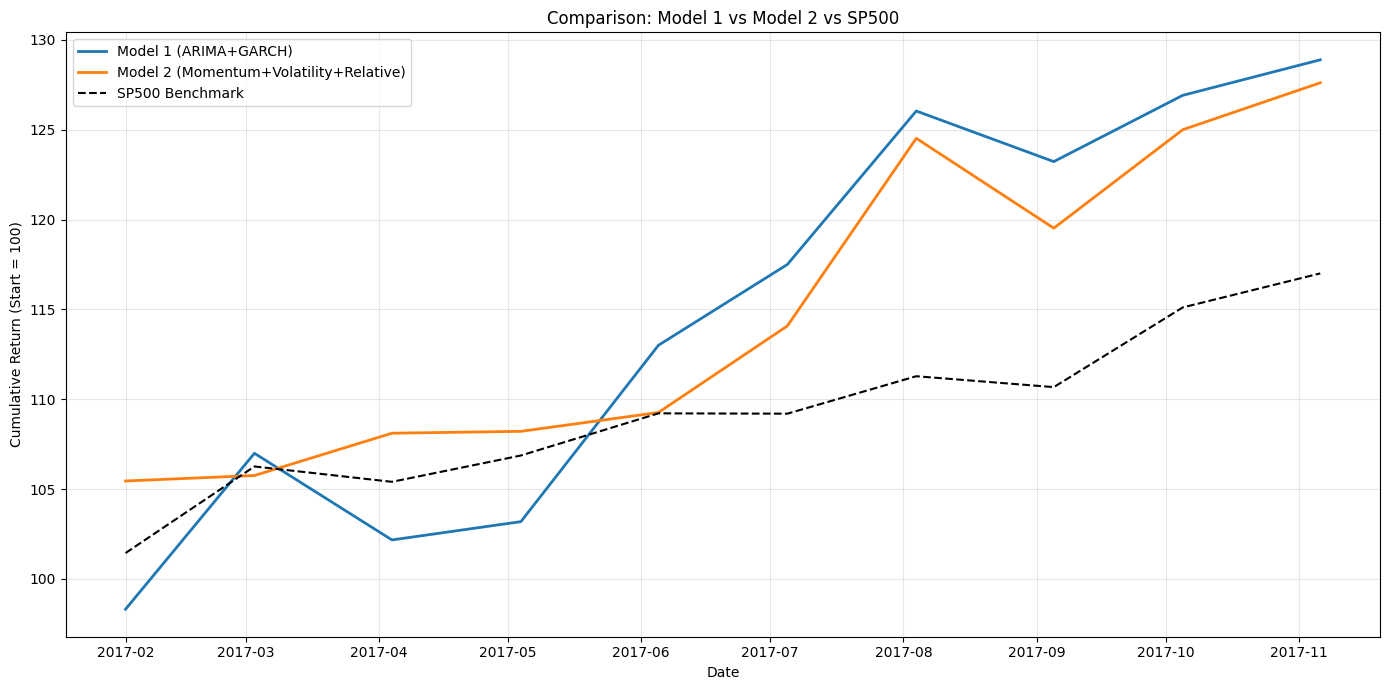

Model 1 Alpha: 11.887254880075702
Model 2 Alpha: 10.608466190294337
Difference (New - Old): -1.278788689781365


In [60]:
plt.figure(figsize=(14, 7))

plt.plot(test_dates, cum_portfolio, label="Model 1 (ARIMA+GARCH)", linewidth=2)
plt.plot(test_dates, cum_portfolio2, label="Model 2 (Momentum+Volatility+Relative)", linewidth=2)

plt.plot(test_dates, cum_spy, label="SP500 Benchmark", linestyle='--', color='black')

plt.title("Comparison: Model 1 vs Model 2 vs SP500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Start = 100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

alpha_old = (cum_portfolio[-1] - 100) - (cum_spy[-1] - 100)
alpha_new = (cum_portfolio2[-1] - 100) - (cum_spy[-1] - 100)

print("Model 1 Alpha:", alpha_old)
print("Model 2 Alpha:", alpha_new)
print("Difference (New - Old):", alpha_new - alpha_old)


From the plot and comparing the alphas we can see that the 1st model is actually better than the 2nd one - it proves that ARIMA and GARCH are indeed importan features for this kind of data. On the other hand, ignoring them and using differen features (volatility, momentum) is still good enough.

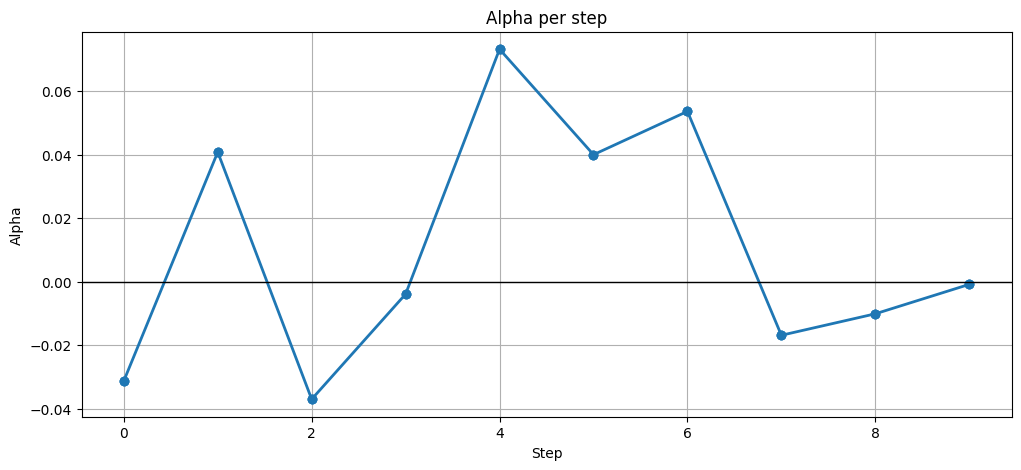

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()

exp = client.get_experiment_by_name("Model_1_Classification_Backtest")
runs = client.search_runs([exp.experiment_id])

rows = []

for r in runs:
    name = r.info.run_name
    metrics = r.data.metrics

    if name.startswith("Step_"):

        for k, v in metrics.items():
            if k.startswith("alpha_step_"):
                step = int(k.replace("alpha_step_", ""))
                rows.append({"step": step, "alpha": v})

df_alpha = pd.DataFrame(rows).sort_values("step")


plt.figure(figsize=(12,5))
plt.plot(df_alpha["step"], df_alpha["alpha"], marker="o", lw=2)
plt.axhline(0, color="black", lw=1)
plt.grid(True)
plt.title("Alpha per step")
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.show()


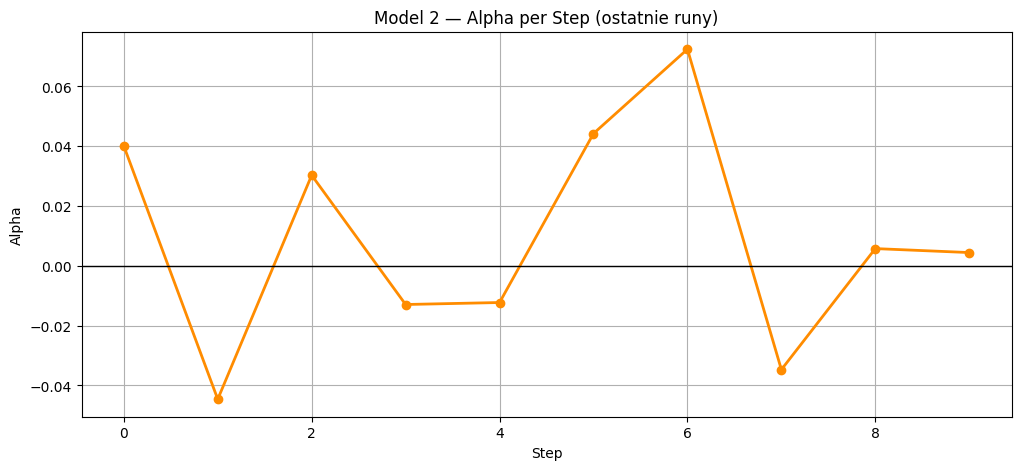

In [ ]:
client = MlflowClient()

exp = client.get_experiment_by_name("Model_2_Classification_Backtest")
runs = client.search_runs([exp.experiment_id])

rows = []

for r in runs:
    name = r.info.run_name
    if name.startswith("Step_") and "Model2" in name:
        metrics = r.data.metrics
        if "alpha_step" in metrics:
            step = int(name.split("_")[1])
            rows.append({
                "step": step,
                "alpha": metrics["alpha_step"],
                "start_time": r.info.start_time,
                "run_id": r.info.run_id,
            })

df = pd.DataFrame(rows)

df_latest = (
    df.sort_values("start_time")
      .groupby("step", as_index=False)
      .tail(1)          # latest run for each step
      .sort_values("step")
)

plt.figure(figsize=(12,5))
plt.plot(df_latest["step"], df_latest["alpha"], marker="o", lw=2, color="darkorange")
plt.axhline(0, color="black", lw=1)
plt.grid(True)
plt.title("Model 2 — Alpha per Step (last run for each step)")
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.show()
